In [53]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
from yellowbrick.cluster import KElbowVisualizer
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.cluster import KMeans
from sksurv.base import SurvivalAnalysisMixin as s
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sksurv.preprocessing import encode_categorical
 
from sksurv.functions import StepFunction
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.ensemble import (ComponentwiseGradientBoostingSurvivalAnalysis, 
                            RandomSurvivalForest, 
                            ExtraSurvivalTrees, 
                            GradientBoostingSurvivalAnalysis, 
                            ExtraSurvivalTrees)
from sksurv.meta import EnsembleSelection, EnsembleSelectionRegressor
from sksurv.metrics import integrated_brier_score
from matplotlib.colors import ListedColormap
from mlxtend.evaluate import paired_ttest_5x2cv
from mlxtend.evaluate import combined_ftest_5x2cv
from lifelines import KaplanMeierFitter
from scipy.cluster import hierarchy
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold, KFold
from lifelines.plotting import add_at_risk_counts
import scipy.stats
import sklearn
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna
from sklearn.model_selection import cross_val_score
from sksurv.metrics import integrated_brier_score
from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import statsmodels.api as sm
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
 
from sklearn.preprocessing import MinMaxScaler


In [54]:
# OUS: Train data
OUS_D1 = pd.read_csv('OUS_D1.csv')
OUS_D2 = pd.read_csv('OUS_D2.csv')
OUS_D3 = pd.read_csv('OUS_D3.csv')
OUS_DFS_target = pd.read_csv('OUS_DFS_target.csv')
OUS_OS_target = pd.read_csv('OUS_OS_target.csv')
response_OUS = pd.read_csv('response_ous.csv', sep=';')

# MAASTRO: Test data 
MAASTRO_D1 = pd.read_csv('MAASTRO_D1.csv')
MAASTRO_D2 = pd.read_csv('MAASTRO_D2.csv')
MAASTRO_D3 = pd.read_csv('MAASTRO_D3.csv')
MAASTRO_DFS_target = pd.read_csv('MAASTRO_DFS_target.csv')
MAASTRO_OS_target = pd.read_csv('MAASTRO_OS_target.csv')
response_MAASTRO = pd.read_csv('maastro_response_full.csv', sep=',')

In [55]:
# Need to choose patient_id from OUS_D3 in response_OUS
data = list(OUS_D3['patient_id'])
mask = response_OUS['patient_id'].isin(data)
response_OUS = response_OUS[mask] 

# Merge OUS_D3 with response_OUS
clinical_train = pd.merge(OUS_D3, response_OUS, on='patient_id', how='inner')
clinical_train = clinical_train.loc[:, ~clinical_train.columns.isin(['OS', 'event_OS', 'LRC', 'event_LRC'])]

In [56]:
# Drop patient_id column
clinical_train = clinical_train.drop('patient_id', axis=1)

In [57]:
# Check null values in D3
clinical_train.isnull().sum().sum()

0

## Test dataset: MAASTRO 

In [58]:
(MAASTRO_D3['patient_id'] == MAASTRO_OS_target['patient_id']).sum()

99

In [59]:
# Rename the column name of response_MAASTRO 
response_MAASTRO.rename(columns = {'Index' : 'patient_id'}, inplace = True)

In [60]:
# need to choose patient_id from MAASTRO_D3 in response_MAASTRO
data = list(MAASTRO_D3['patient_id'])
mask = response_MAASTRO['patient_id'].isin(data)
response_MAASTRO = response_MAASTRO[mask] 
response_MAASTRO

,patient_id,OS,OS_event,LRC,LRC_event,DFS,DFS_event
0,1,62.43,0.0,62.43,0.0,62.43,0.0
1,2,60.00,0.0,60.00,0.0,60.00,0.0
2,3,44.43,1.0,8.83,1.0,8.83,1.0
3,4,37.20,1.0,19.37,0.0,19.73,1.0
5,6,59.23,0.0,59.23,0.0,59.23,0.0
...,...,...,...,...,...,...,...
109,110,19.00,1.0,13.27,1.0,13.27,1.0
110,111,85.87,1.0,82.83,0.0,85.87,1.0
111,112,42.87,0.0,42.87,0.0,42.87,0.0
112,113,58.93,0.0,58.93,0.0,58.93,0.0


In [61]:
# Merge MAASTRO_D3 with response_MAASTRO
clinical_test = pd.merge(MAASTRO_D3, response_MAASTRO, on='patient_id', how='inner')
clinical_test = clinical_test.loc[:, ~clinical_test.columns.isin(['OS', 'OS_event', 'LRC', 'LRC_event'])]
clinical_test

,patient_id,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event
0,1,55,0,0,1,0,0,1,1,1,...,0.028808,0.837387,0.000026,0.001705,0.122209,0.000026,0.008291,0.000341,62.43,0.0
1,2,55,0,0,1,0,0,0,0,0,...,0.049615,0.806842,0.000167,0.002958,0.128976,0.000167,0.008148,0.000335,60.00,0.0
2,3,55,0,0,1,0,0,0,0,1,...,0.019514,0.830272,0.000057,0.001831,0.137282,0.000000,0.008641,0.000229,8.83,1.0
3,4,61,1,0,0,0,1,1,0,1,...,0.047155,0.760949,0.000000,0.003597,0.171595,0.000080,0.013187,0.000240,19.73,1.0
4,6,70,0,0,1,0,0,1,1,1,...,0.033990,0.824865,0.000000,0.002116,0.128134,0.000035,0.009379,0.000529,59.23,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,110,66,1,0,0,0,1,0,0,0,...,0.017489,0.834590,0.000000,0.001321,0.137194,0.000078,0.008706,0.000078,13.27,1.0
95,111,63,0,0,0,0,1,0,0,1,...,0.029979,0.821431,0.000000,0.000543,0.137620,0.000054,0.008907,0.000489,85.87,1.0
96,112,63,0,0,1,0,0,1,1,1,...,0.017354,0.859957,0.000000,0.000988,0.115099,0.000028,0.005700,0.000141,42.87,0.0
97,113,54,0,0,1,0,0,1,1,0,...,0.025399,0.847908,0.000000,0.001487,0.117654,0.000000,0.005759,0.000038,58.93,0.0


In [62]:
# Drop patient_id column
clinical_test = clinical_test.drop('patient_id', axis=1)

In [63]:
# Some rows have null values in OS, OS_event -> Remove those rows
clinical_test[clinical_test.isnull().any(axis=1)]
clinical_test = clinical_test.dropna(how='any',axis=0) 

,age,female,cavum_oris,oropharynx,hypopharynx,larynx,histgrade_high,hpv_related,charlson,pack_years,...,LBP_021_PET,LBP_030_PET,LBP_102_PET,LBP_111_PET,LBP_120_PET,LBP_201_PET,LBP_210_PET,LBP_300_PET,DFS,DFS_event


In [64]:
# X
X = clinical_train.loc[:, ~clinical_train.columns.isin(['DFS', 'event_DFS'])]

# y 
y = clinical_train.loc[:, ['DFS', 'event_DFS']]

In [65]:
# Set lower, upper time point and times for IBS calculation later 
lower, upper = np.percentile(y['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [66]:
# Shape
print('X_train: ', X.shape)
print('y_train: ', y.shape)

X_train:  (139, 388)
y_train:  (139,)


In [67]:
clinical_test.rename(columns = {'DFS_event' : 'event_DFS'}, inplace = True)

In [68]:
# X
X_MAASTRO = clinical_test.loc[:, ~clinical_test.columns.isin(['DFS', 'event_DFS'])]

# y y_MAASTRO
y_MAASTRO = clinical_test.loc[:, ['DFS', 'event_DFS']]
lower, upper = np.percentile(y_MAASTRO['DFS'], [10, 90])
times = np.arange(lower, upper)

# y into array 
lists = [] 
for i, j in zip(y_MAASTRO['event_DFS'], y_MAASTRO['DFS']): 
    lists.append((i, j))

y_MAASTRO = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

clinical_test.shape

(99, 390)

# Standardization for Clustering

In [69]:
original_X = X.copy()

In [70]:
# Standardize the data 
## Save the column and index 
X_columns = X.columns 
X_index = X.index

## Standardize the data but not the categorical columns
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

### Separate the categorical and non-categorical columns
X_categorical = X[categorical_columns]
X_numeric = X.drop(categorical_columns, axis=1)
X_numeric_columns = X_numeric.columns
X_numeric_index = X_numeric.index

### Standardize non-categorical and then concat with the categorical
scaler = MinMaxScaler()  
X_numeric_std = scaler.fit_transform(X_numeric)
X_numeric_std = pd.DataFrame(X_numeric_std, columns=X_numeric_columns, index=X_numeric_index)
X_std = pd.concat([X_categorical, X_numeric_std], axis=1)

## Sort the order of the columns as it was in the clinical train 
X_std = X_std[original_X.columns]

## Feature Selection

KElbowVisualizer(ax=<AxesSubplot:>, estimator=KMeans(n_clusters=9), k=(2, 10))

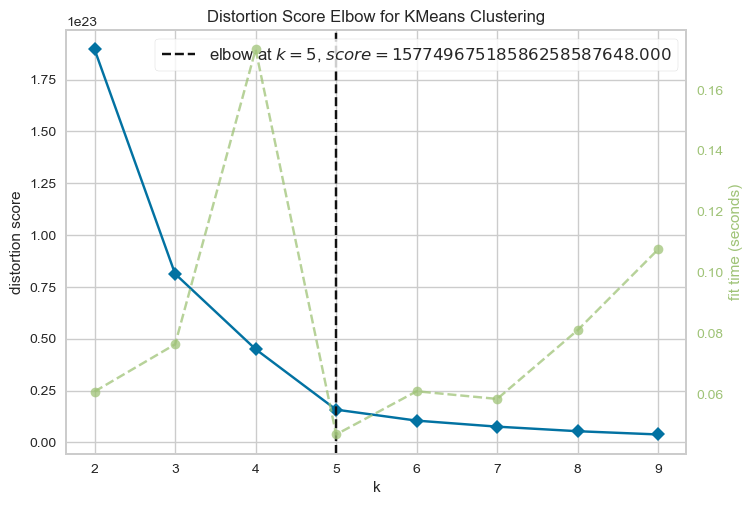

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [71]:
# How many clusters to form - 1. Using elbow method 
X_transposed = X_std.T

kmeans = KMeans()
ssd = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k).fit(X_transposed)
    ssd.append(kmeans.inertia_)

kmeans = KMeans()
visu = KElbowVisualizer(kmeans, k=(2, 10))
visu.fit(clinical_train)
visu.show()

In [72]:
num_clusters = 5  
kmeans = KMeans(n_clusters=num_clusters)
kmeans.fit(X_std.T)
cluster_labels = kmeans.labels_

selected_features = [] 
for i in range(5):
    variance = X_std[X_std.columns[cluster_labels==i]].var()

    # Find the most correlated column
    high_variance_column = variance.abs().idxmax()

    # Get the correlation coefficient of the most correlated column
    max_variance = variance.abs().max()

    print(i)
    print("Most correlated column:", high_variance_column)
    print("Correlation coefficient:", max_variance)
    print('\n')
    selected_features.append(high_variance_column)

KMeans(n_clusters=5)

0
Most correlated column: hypopharynx
Correlation coefficient: 0.10259618392242767


1
Most correlated column: uicc8_III-IV
Correlation coefficient: 0.25148576790741356


2
Most correlated column: hpv_related
Correlation coefficient: 0.2460640183505367


3
Most correlated column: female
Correlation coefficient: 0.17850067771869405


4
Most correlated column: charlson
Correlation coefficient: 0.23761860077155636




In [73]:
# Selecting features in the DataFrame
X_fs_hv = X[selected_features]
X_new = X_fs_hv.copy()

X_MAASTRO_fs_hv = X_MAASTRO[selected_features]
MAASTRO_new = X_MAASTRO_fs_hv.copy()

# Standardization

In [74]:
"""
# Standardize X_new, the new data with the selected features only 
categorical_columns = ['female', 
                        'cavum_oris',
                        'oropharynx',
                        'hypopharynx',
                        'larynx',
                        'histgrade_high',
                        'hpv_related',
                        'charlson',
                        'uicc8_III-IV']

# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in X_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
X_new_categoric = X_new[columns_to_drop]
X_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
scaler = MinMaxScaler() 
X_new_numeric_columns = X_new_numeric.columns
X_new_numeric_index = X_new_numeric.index 
X_new_numeric_std = scaler.fit_transform(X_new_numeric)
X_new_numeric_std = pd.DataFrame(X_new_numeric_std,
                                 columns=X_new_numeric_columns, 
                                 index=X_new_numeric_index)
X_new_std = pd.concat([X_new_numeric_std, X_new_categoric], axis=1)

# Change the order of the X_new_std 
"""
X_new_std = X_new

"\n# Standardize X_new, the new data with the selected features only \ncategorical_columns = ['female', \n                        'cavum_oris',\n                        'oropharynx',\n                        'hypopharynx',\n                        'larynx',\n                        'histgrade_high',\n                        'hpv_related',\n                        'charlson',\n                        'uicc8_III-IV']\n\n# Set the columns_to_drop which are categorical \ncolumns_to_drop = [col for col in X_new.columns if col in categorical_columns]\n\n# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric\nX_new_categoric = X_new[columns_to_drop]\nX_new_numeric = X_new.drop(columns=columns_to_drop, inplace=False)\n\n# Do the standardization for the numeric part \nscaler = MinMaxScaler() \nX_new_numeric_columns = X_new_numeric.columns\nX_new_numeric_index = X_new_numeric.index \nX_new_numeric_std = scaler.fit_transform(X_new_numeric)\nX_new_numeric_std 

In [75]:
"""
# Standardize X_MAASTRO 
# Set the columns_to_drop which are categorical 
columns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]

# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric
MAASTRO_new_categoric = MAASTRO_new[columns_to_drop]
MAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)

# Do the standardization for the numeric part 
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns
MAASTRO_new_numeric_index = MAASTRO_new_numeric.index 
MAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)
MAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,
                                 columns=MAASTRO_new_numeric_columns, 
                                 index=MAASTRO_new_numeric_index)
MAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)

# Change the order of the X_new_std 

""" 
MAASTRO_new_std = MAASTRO_new

'\n# Standardize X_MAASTRO \n# Set the columns_to_drop which are categorical \ncolumns_to_drop = [col for col in MAASTRO_new.columns if col in categorical_columns]\n\n# Drop the columns if they exist in the DataFrame and save the numeric part in X_new_numeric\nMAASTRO_new_categoric = MAASTRO_new[columns_to_drop]\nMAASTRO_new_numeric = MAASTRO_new.drop(columns=columns_to_drop, inplace=False)\n\n# Do the standardization for the numeric part \nMAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns\nMAASTRO_new_numeric_columns = MAASTRO_new_numeric.columns\nMAASTRO_new_numeric_index = MAASTRO_new_numeric.index \nMAASTRO_new_numeric_std = scaler.transform(MAASTRO_new_numeric)\nMAASTRO_new_numeric_std = pd.DataFrame(MAASTRO_new_numeric_std,\n                                 columns=MAASTRO_new_numeric_columns, \n                                 index=MAASTRO_new_numeric_index)\nMAASTRO_new_std = pd.concat([MAASTRO_new_numeric_std, MAASTRO_new_categoric], axis=1)\n\n# Change the order of t

In [76]:
X_new

,hypopharynx,uicc8_III-IV,hpv_related,female,charlson
0,0,0.0,0.0,1,0
1,0,0.0,0.0,0,1
2,0,1.0,0.0,0,1
3,0,0.0,0.0,0,1
4,0,0.0,0.0,0,1
...,...,...,...,...,...
134,0,0.0,1.0,0,0
135,0,1.0,1.0,0,0
136,0,0.0,1.0,0,1
137,0,1.0,1.0,0,1


In [77]:
X_new_std

,hypopharynx,uicc8_III-IV,hpv_related,female,charlson
0,0,0.0,0.0,1,0
1,0,0.0,0.0,0,1
2,0,1.0,0.0,0,1
3,0,0.0,0.0,0,1
4,0,0.0,0.0,0,1
...,...,...,...,...,...
134,0,0.0,1.0,0,0
135,0,1.0,1.0,0,0
136,0,0.0,1.0,0,1
137,0,1.0,1.0,0,1


In [78]:
MAASTRO_new

,hypopharynx,uicc8_III-IV,hpv_related,female,charlson
0,0,0,1,0,1
1,0,1,0,0,0
2,0,1,0,0,1
3,0,1,0,1,1
4,0,0,1,0,1
...,...,...,...,...,...
94,0,1,0,1,0
95,0,1,0,0,1
96,0,1,1,0,1
97,0,0,1,0,0


In [79]:
MAASTRO_new_std

,hypopharynx,uicc8_III-IV,hpv_related,female,charlson
0,0,0,1,0,1
1,0,1,0,0,0
2,0,1,0,0,1
3,0,1,0,1,1
4,0,0,1,0,1
...,...,...,...,...,...
94,0,1,0,1,0
95,0,1,0,0,1
96,0,1,1,0,1
97,0,0,1,0,0


# Modelling 

### 1. CoxPHSurvivalAnalysis

#### Train

In [80]:
# Setting the y format for skf below  
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class()
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxPHSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxPHSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 09:39:13,612] A new study created in memory with name: no-name-c2229d8d-08f0-4fe7-94b9-f6eda7b25bfc
python(9895) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  0%|          | 0/1 [00:00<?, ?it/s]

[I 2024-04-16 09:39:14,245] A new study created in memory with name: no-name-47700f03-0058-4964-930e-0633751a757e


Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.5542635658914729
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.628755364806867
[I 2024-04-16 09:39:14,214] Trial 0 finished with value: 0.6469599603426215 and parameters: {}. Best is trial 0 with value: 0.6469599603426215.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6469599603426215], datetime_start=datetime.datetime(2024, 4, 16, 9, 39, 13, 943676), datetime_complete=datetime.datetime(2024, 4, 16, 9, 39, 14, 213468), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6469599603426215


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.2317193276889126
Fold 2 IBS: 0.24914010602407072
Fold 3 IBS: 0.18886953346869295
Fold 4 IBS: 0.22948653509110617
Fold 5 IBS: 0.1986129299181226
[I 2024-04-16 09:39:14,488] Trial 0 finished with value: 0.21956568643818103 and parameters: {}. Best is trial 0 with value: 0.21956568643818103.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21956568643818103], datetime_start=datetime.datetime(2024, 4, 16, 9, 39, 14, 285042), datetime_complete=datetime.datetime(2024, 4, 16, 9, 39, 14, 487877), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21956568643818103


In [81]:
# Setting a dictionary to save the train results 
train_cindex = {} 
train_ibs = {} 

# Saving the values to the dictionary 
train_cindex['CoxPH'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxPH'] = np.round(study_ibs.best_value, 3)

In [82]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.647
train_ibs:  0.22


#### Test

In [83]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [84]:
# Test on MAASTRO 
cph = CoxPHSurvivalAnalysis()

cph.fit(X_new_std, y)

# Save C-index 
c_index = cph.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print('Concordance index:', c_index)

# Save IBS 
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in cph.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print('IBS score:', ibs)

CoxPHSurvivalAnalysis()

Concordance index: 0.579
IBS score: 0.247


In [85]:
# Setting a dictionary to save the test results 
test_cindex = {} 
test_ibs = {} 

In [86]:
# Saving the values to the dictionary 
test_cindex['CoxPH'] = c_index
test_ibs['CoxPH'] = ibs

### 2. CoxnetSurvivalAnalysis - Ridge

#### Train

In [87]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning 
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=0.0000001, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 09:39:14,719] A new study created in memory with name: no-name-5a1fd314-0fd6-4d85-b895-c218f4181ad8


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6065891472868217
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6939163498098859
Fold 5 C-index: 0.6223175965665236
[I 2024-04-16 09:39:14,871] Trial 0 finished with value: 0.6530227012960098 and parameters: {}. Best is trial 0 with value: 0.6530227012960098.


[I 2024-04-16 09:39:14,879] A new study created in memory with name: no-name-24d2f632-756d-4559-91e5-5e288970360c




* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6530227012960098], datetime_start=datetime.datetime(2024, 4, 16, 9, 39, 14, 801903), datetime_complete=datetime.datetime(2024, 4, 16, 9, 39, 14, 871788), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6530227012960098


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.24724709740463627
Fold 2 IBS: 0.23203988107242277
Fold 3 IBS: 0.22898186333477166
Fold 4 IBS: 0.2419747676475077
Fold 5 IBS: 0.22939558866148296
[I 2024-04-16 09:39:15,053] Trial 0 finished with value: 0.23592783962416428 and parameters: {}. Best is trial 0 with value: 0.23592783962416428.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.23592783962416428], datetime_start=datetime.datetime(2024, 4, 16, 9, 39, 14, 918177), datetime_complete=datetime.datetime(2024, 4, 16, 9, 39, 15, 52891), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.23592783962416428


In [88]:
train_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

In [89]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.653
train_ibs:  0.236


#### Test

In [90]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [91]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 0.0000001
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_cindex : 0.601


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1e-07)

test_ibs:  0.229


In [92]:
test_cindex['CoxRidge'] = np.round(study_cindex.best_value, 3)
test_ibs['CoxRidge'] = np.round(study_ibs.best_value, 3)

### 3. CoxnetSurvivalAnalysis - Lasso

#### Train

In [93]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Create and fit survival model 
        model = model_class(l1_ratio=1, 
                            fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=1, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 09:39:15,303] A new study created in memory with name: no-name-552e34c4-336c-4236-9019-20dc9b4ae5c0


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 C-index: 0.6155378486055777


[I 2024-04-16 09:39:15,586] A new study created in memory with name: no-name-1b11e88d-a97c-4c20-b45f-5cb0a941cf2a


Fold 2 C-index: 0.5542635658914729
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6244635193133047
[I 2024-04-16 09:39:15,581] Trial 0 finished with value: 0.6461015912439091 and parameters: {}. Best is trial 0 with value: 0.6461015912439091.


* Best trial for C-index: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.6461015912439091], datetime_start=datetime.datetime(2024, 4, 16, 9, 39, 15, 341195), datetime_complete=datetime.datetime(2024, 4, 16, 9, 39, 15, 581341), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for C-index: 
 0.6461015912439091


  0%|          | 0/1 [00:00<?, ?it/s]

Fold 1 IBS: 0.23091543241019963
Fold 2 IBS: 0.2469090024162656
Fold 3 IBS: 0.18869706938975456
Fold 4 IBS: 0.22921903381662886
Fold 5 IBS: 0.19928531483437917
[I 2024-04-16 09:39:15,878] Trial 0 finished with value: 0.21900517057344557 and parameters: {}. Best is trial 0 with value: 0.21900517057344557.


* Best trial for IBS: 
 FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.21900517057344557], datetime_start=datetime.datetime(2024, 4, 16, 9, 39, 15, 636254), datetime_complete=datetime.datetime(2024, 4, 16, 9, 39, 15, 878143), params={}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={}, trial_id=0, value=None)


* Best Score for IBS: 
 0.21900517057344557


In [94]:
train_cindex['CoxLasso'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxLasso'] = np.round(study_ibs.best_value, 3)

In [95]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.646
train_ibs:  0.219


#### Test

In [96]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [97]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params['l1_ratio'] = 1
    best_params['fit_baseline_model']=True
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_cindex : 0.579


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=1)

test_ibs:  0.245


In [98]:
# Saving the values to the dictionary 
test_cindex['CoxLasso'] = c_index
test_ibs['CoxLasso'] = ibs

### 4. CoxnetSurvivalAnalysis - ElasticNet

#### Train

In [99]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        l1_ratio = trial.suggest_float("l1_ratio", 0.0001, 1)
        
        # Create and fit survival model 
        model = model_class(l1_ratio=l1_ratio, 
                           fit_baseline_model=True)
        
        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(CoxnetSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(CoxnetSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 09:39:16,101] A new study created in memory with name: no-name-8a21fa16-e73d-4ea9-9a45-3bbae5ddb9da


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.5542635658914729
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6244635193133047
[I 2024-04-16 09:39:16,364] Trial 0 finished with value: 0.6461015912439091 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.6461015912439091.
Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.5542635658914729
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6244635193133047
[I 2024-04-16 09:39:16,607] Trial 1 finished with value: 0.6461015912439091 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 0 with value: 0.6461015912439091.
Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.5542635658914729
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6244635193133047
[I 2024-04-16 09:39:16,831] Trial 2 finished with value: 0.6461015912439091 and parameters: {'l1_ratio': 0.22692876841884668}.

Fold 5 C-index: 0.6244635193133047
[I 2024-04-16 09:39:20,467] Trial 23 finished with value: 0.6461015912439091 and parameters: {'l1_ratio': 0.3109902564784235}. Best is trial 15 with value: 0.657037543215884.
Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.5542635658914729
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6244635193133047
[I 2024-04-16 09:39:20,727] Trial 24 finished with value: 0.6461015912439091 and parameters: {'l1_ratio': 0.2402337233088126}. Best is trial 15 with value: 0.657037543215884.
Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.6065891472868217
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6939163498098859
Fold 5 C-index: 0.6201716738197425
[I 2024-04-16 09:39:20,831] Trial 25 finished with value: 0.6561791741171715 and parameters: {'l1_ratio': 0.10919740482940127}. Best is trial 15 with value: 0.657037543215884.
Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.5542635658914729
Fold 3 C-index: 0.7

Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.5542635658914729
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6244635193133047
[I 2024-04-16 09:39:24,662] Trial 47 finished with value: 0.6461015912439091 and parameters: {'l1_ratio': 0.6240103588601071}. Best is trial 15 with value: 0.657037543215884.
Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.5542635658914729
Fold 3 C-index: 0.7404255319148936
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6244635193133047
[I 2024-04-16 09:39:24,929] Trial 48 finished with value: 0.6461015912439091 and parameters: {'l1_ratio': 0.7991933234425521}. Best is trial 15 with value: 0.657037543215884.
Fold 1 C-index: 0.6155378486055777
Fold 2 C-index: 0.5542635658914729
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6244635193133047
[I 2024-04-16 09:39:25,220] Trial 49 finished with value: 0.6469526550736964 and parameters: {'l1_ratio': 0.16989740498669767

...

  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 IBS: 0.2309279774465704
Fold 2 IBS: 0.2468228723537316
Fold 3 IBS: 0.1887170939144328
Fold 4 IBS: 0.22918670679352704
Fold 5 IBS: 0.19931636070247727
[I 2024-04-16 09:39:33,647] Trial 0 finished with value: 0.21899420224214783 and parameters: {'l1_ratio': 0.6964995386793018}. Best is trial 0 with value: 0.21899420224214783.
Fold 1 IBS: 0.23104019081755503
Fold 2 IBS: 0.24663612466629373
Fold 3 IBS: 0.18874915114809226
Fold 4 IBS: 0.2290730275759248
Fold 5 IBS: 0.1993242486643085
[I 2024-04-16 09:39:33,946] Trial 1 finished with value: 0.21896454857443487 and parameters: {'l1_ratio': 0.28621072101688444}. Best is trial 1 with value: 0.21896454857443487.
Fold 1 IBS: 0.23108602968176137
Fold 2 IBS: 0.24654933139793964
Fold 3 IBS: 0.1887600293780863
Fold 4 IBS: 0.22906037822746766
Fold 5 IBS: 0.19930379791317065
[I 2024-04-16 09:39:34,242] Trial 2 finished with value: 0.2189519133196851 and parameters: {'l1_ratio': 0.22692876841884668}. Best is trial 2 with value: 0.2189519133196851

Fold 1 IBS: 0.231071213044465
Fold 2 IBS: 0.24664519698353735
Fold 3 IBS: 0.1887555423956727
Fold 4 IBS: 0.22907531520021215
Fold 5 IBS: 0.19930252750929334
[I 2024-04-16 09:39:40,440] Trial 25 finished with value: 0.21896995902663613 and parameters: {'l1_ratio': 0.26069125348605016}. Best is trial 16 with value: 0.21893984827073298.
Fold 1 IBS: 0.23112599396395841
Fold 2 IBS: 0.2465762577204394
Fold 3 IBS: 0.22315435365240396
Fold 4 IBS: 0.23747350372815731
Fold 5 IBS: 0.19930110542235177
[I 2024-04-16 09:39:40,691] Trial 26 finished with value: 0.22752624289746218 and parameters: {'l1_ratio': 0.15628602804532354}. Best is trial 16 with value: 0.21893984827073298.
Fold 1 IBS: 0.2310370746625405
Fold 2 IBS: 0.24666283788922763
Fold 3 IBS: 0.18873509706873098
Fold 4 IBS: 0.22907566152328812
Fold 5 IBS: 0.19929915110029883
[I 2024-04-16 09:39:40,969] Trial 27 finished with value: 0.21896196444881721 and parameters: {'l1_ratio': 0.35245417491105274}. Best is trial 16 with value: 0.2189398

Fold 1 IBS: 0.23118492903043739
Fold 2 IBS: 0.22899947703174367
Fold 3 IBS: 0.2247584740849755
Fold 4 IBS: 0.23867603893995448
Fold 5 IBS: 0.2255072664639626
[I 2024-04-16 09:39:46,404] Trial 50 finished with value: 0.22982523711021474 and parameters: {'l1_ratio': 0.10507868659302694}. Best is trial 16 with value: 0.21893984827073298.
Fold 1 IBS: 0.23105851530530466
Fold 2 IBS: 0.24656334759727264
Fold 3 IBS: 0.18874138559269135
Fold 4 IBS: 0.22906031919734876
Fold 5 IBS: 0.19929537633132055
[I 2024-04-16 09:39:46,755] Trial 51 finished with value: 0.2189437888047876 and parameters: {'l1_ratio': 0.305715254106444}. Best is trial 16 with value: 0.21893984827073298.
Fold 1 IBS: 0.23100024858519838
Fold 2 IBS: 0.24659667379677455
Fold 3 IBS: 0.1887222122294319
Fold 4 IBS: 0.22913023710975
Fold 5 IBS: 0.19928723126543124
[I 2024-04-16 09:39:47,127] Trial 52 finished with value: 0.21894732059731722 and parameters: {'l1_ratio': 0.5101281828983963}. Best is trial 16 with value: 0.218939848270

Fold 1 IBS: 0.23104451226774364
Fold 2 IBS: 0.24650448217198728
Fold 3 IBS: 0.1887358983613075
Fold 4 IBS: 0.22908610899037182
Fold 5 IBS: 0.19935248869616076
[I 2024-04-16 09:39:55,770] Trial 75 finished with value: 0.2189446980975142 and parameters: {'l1_ratio': 0.36296499067626914}. Best is trial 74 with value: 0.2189334494383126.
Fold 1 IBS: 0.23105219883374728
Fold 2 IBS: 0.2465093081348735
Fold 3 IBS: 0.18875037313698584
Fold 4 IBS: 0.22908845943138792
Fold 5 IBS: 0.19930531828140258
[I 2024-04-16 09:39:56,088] Trial 76 finished with value: 0.21894113156367942 and parameters: {'l1_ratio': 0.2987172393502055}. Best is trial 74 with value: 0.2189334494383126.
Fold 1 IBS: 0.23114982635336498
Fold 2 IBS: 0.2465247743899641
Fold 3 IBS: 0.22281442034150908
Fold 4 IBS: 0.22901859106764125
Fold 5 IBS: 0.19932580309526202
[I 2024-04-16 09:39:56,436] Trial 77 finished with value: 0.22576668304954825 and parameters: {'l1_ratio': 0.16826100451470372}. Best is trial 74 with value: 0.218933449

In [100]:
train_cindex['CoxElastic'] = np.round(study_cindex.best_value, 3)
train_ibs['CoxElastic'] = np.round(study_ibs.best_value, 3)

In [101]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.657
train_ibs:  0.219


#### Test

In [102]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [103]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    return model_class(**best_params, fit_baseline_model=True)

# Set the best model 
best_model_cindex = create_best_model(CoxnetSurvivalAnalysis, 
                                      study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex :", c_index)

# Set the best model 
best_model_ibs = create_best_model(CoxnetSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.13901336863085584)

test_cindex : 0.579


CoxnetSurvivalAnalysis(fit_baseline_model=True, l1_ratio=0.2172133635903008)

test_ibs:  0.245


In [104]:
# Saving the values to the dictionary 
test_cindex['CoxElastic'] = c_index
test_ibs['CoxElastic'] = ibs

### 5. Random Survival Forest

#### Train

In [105]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None])
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics
        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score,
                            warm_start=warm_start,
                            max_depth=max_depth,
                            max_features=max_features,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_samples=max_samples, 
                            random_state=123)

        scores = [] 

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])
            
            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                cox_surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, cox_surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(RandomSurvivalForest, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(RandomSurvivalForest, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 09:40:03,415] A new study created in memory with name: no-name-d67d90ce-c27c-4c21-9583-8f8a81305521


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.7574468085106383
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6115879828326181
[I 2024-04-16 09:40:07,278] Trial 0 finished with value: 0.658623503095328 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'max_samples': 0.7163467647263769, 'max_features': None, 'min_weight_fraction_leaf': 0.2192861223398122, 'warm_start': False}. Best is trial 0 with value: 0.658623503095328.
Fold 1 C-index: 0.5756972111553785
Fold 2 C-index: 0.5891472868217055
Fold 3 C-index: 0.7702127659574468
Fold 4 C-index: 0.7034220532319392
Fold 5 C-index: 0.6115879828326181
[I 2024-04-16 09:40:09,792] Trial 1 finished with value: 0.6500134599998175 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 5, 'min_samples_leaf': 4, 'max_depth': 11, 'n_estimators': 266, 'oob_score': False, 'max_samples': 0.7520097923745717, 'm

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 09:40:40,247] Trial 16 finished with value: 0.5 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 9, 'min_samples_leaf': 1, 'max_depth': 1, 'n_estimators': 62, 'oob_score': True, 'max_samples': 0.48642459971721597, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.4304758045145193, 'warm_start': True}. Best is trial 2 with value: 0.6657472883260915.
Fold 1 C-index: 0.6235059760956175
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.7702127659574468
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6158798283261803
[I 2024-04-16 09:40:41,226] Trial 17 finished with value: 0.6620134447328477 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 2, 'min_samples_leaf': 8, 'max_depth': 4, 'n_estimators': 202, 'oob_score': True, 'max_samples': 0.9893519173022722, 'max_features': 'auto', 'min_weight_fraction_leaf': 0.36983114470542827, 'warm_start': True

Fold 1 C-index: 0.6235059760956175
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7702127659574468
Fold 4 C-index: 0.7129277566539924
Fold 5 C-index: 0.6158798283261803
[I 2024-04-16 09:40:50,518] Trial 31 finished with value: 0.6669858855616861 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 9, 'min_samples_leaf': 12, 'max_depth': 6, 'n_estimators': 163, 'oob_score': True, 'max_samples': 0.9917138438084729, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.2114962075704278, 'warm_start': True}. Best is trial 28 with value: 0.6798575681360857.
Fold 1 C-index: 0.5717131474103586
Fold 2 C-index: 0.6395348837209303
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.7414448669201521
Fold 5 C-index: 0.6759656652360515
[I 2024-04-16 09:40:51,713] Trial 32 finished with value: 0.6823274573383497 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 8, 'min_samples_leaf': 11, 'max_depth': 3, 'n_estimators': 238, 'oob_score': True, 'max_samples': 0.9970849751440904,

...

Fold 5 IBS: 0.2114054980678314
[I 2024-04-16 09:44:42,822] Trial 31 finished with value: 0.21641973329574862 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 16, 'min_samples_leaf': 3, 'max_depth': 16, 'n_estimators': 311, 'oob_score': True, 'max_samples': 0.20551248039023065, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.05894443856420177}. Best is trial 23 with value: 0.21372354397804721.
Fold 1 IBS: 0.22771764688761698
Fold 2 IBS: 0.21892861811217662
Fold 3 IBS: 0.19577191621417098
Fold 4 IBS: 0.22314467722253584
Fold 5 IBS: 0.2080706394054109
[I 2024-04-16 09:44:46,478] Trial 32 finished with value: 0.21472669956838225 and parameters: {'min_samples_split': 10, 'max_leaf_nodes': 19, 'min_samples_leaf': 4, 'max_depth': 18, 'n_estimators': 272, 'oob_score': True, 'max_samples': 0.42288824569159966, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.07421057700515879}. Best is trial 23 with value: 0.21372354397804721.
Fold 1 IBS: 0.24330283912512352
Fold 2 IBS: 0.

Fold 1 IBS: 0.23090055263490283
Fold 2 IBS: 0.21939129837476573
Fold 3 IBS: 0.19511229332210459
Fold 4 IBS: 0.2204406910190891
Fold 5 IBS: 0.20335503982133693
[I 2024-04-16 09:45:36,680] Trial 47 finished with value: 0.21383997503443983 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 20, 'min_samples_leaf': 6, 'max_depth': 7, 'n_estimators': 224, 'oob_score': True, 'max_samples': 0.4419987409830474, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.02056971261511431}. Best is trial 35 with value: 0.21345087949504243.
Fold 1 IBS: 0.24478028149628311
Fold 2 IBS: 0.22312172675543582
Fold 3 IBS: 0.19955560718988646
Fold 4 IBS: 0.21474218582388693
Fold 5 IBS: 0.2021751260626249
[I 2024-04-16 09:45:37,583] Trial 48 finished with value: 0.21687498546562348 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 18, 'min_samples_leaf': 2, 'max_depth': 6, 'n_estimators': 79, 'oob_score': False, 'max_samples': 0.23963098703208563, 'max_features': 'auto', 'min_weight_fraction_le

Fold 5 IBS: 0.20308700212959255
[I 2024-04-16 09:46:05,714] Trial 62 finished with value: 0.2132793810994403 and parameters: {'min_samples_split': 11, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 201, 'oob_score': False, 'max_samples': 0.3522997850779123, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.013236147487067241}. Best is trial 56 with value: 0.21313357374795014.
Fold 1 IBS: 0.22879819495504053
Fold 2 IBS: 0.2187161541387647
Fold 3 IBS: 0.19670468162250684
Fold 4 IBS: 0.22248159100740342
Fold 5 IBS: 0.2081471943535367
[I 2024-04-16 09:46:07,212] Trial 63 finished with value: 0.2149695632154504 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 18, 'min_samples_leaf': 7, 'max_depth': 12, 'n_estimators': 200, 'oob_score': False, 'max_samples': 0.34319456067785076, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.006629905410983072}. Best is trial 56 with value: 0.21313357374795014.
Fold 1 IBS: 0.22516596854040488
Fold 2 IBS: 0

Fold 1 IBS: 0.2326066175380646
Fold 2 IBS: 0.21928348554975832
Fold 3 IBS: 0.19686589180792408
Fold 4 IBS: 0.2169368757200654
Fold 5 IBS: 0.20668897090230387
[I 2024-04-16 09:46:23,406] Trial 78 finished with value: 0.21447636830362327 and parameters: {'min_samples_split': 16, 'max_leaf_nodes': 17, 'min_samples_leaf': 6, 'max_depth': 16, 'n_estimators': 132, 'oob_score': False, 'max_samples': 0.4196644241470548, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.04437983927293186}. Best is trial 66 with value: 0.2125721839704755.
Fold 1 IBS: 0.22685491154326357
Fold 2 IBS: 0.2190609804084271
Fold 3 IBS: 0.19812261489588484
Fold 4 IBS: 0.22395053788191863
Fold 5 IBS: 0.20952480035341423
[I 2024-04-16 09:46:24,656] Trial 79 finished with value: 0.2155027690165817 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 16, 'min_samples_leaf': 9, 'max_depth': 18, 'n_estimators': 181, 'oob_score': False, 'max_samples': 0.3562183967014979, 'max_features': 'sqrt', 'min_weight_fraction_

Fold 5 IBS: 0.20090685803524327
[I 2024-04-16 09:46:40,578] Trial 93 finished with value: 0.21450349594849194 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 18, 'min_samples_leaf': 3, 'max_depth': 16, 'n_estimators': 148, 'oob_score': False, 'max_samples': 0.3638491256478538, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.026620753574549374}. Best is trial 66 with value: 0.2125721839704755.
Fold 1 IBS: 0.2340494918166715
Fold 2 IBS: 0.2199493683641232
Fold 3 IBS: 0.19792300997720447
Fold 4 IBS: 0.21630226446326442
Fold 5 IBS: 0.20328747503037284
[I 2024-04-16 09:46:41,529] Trial 94 finished with value: 0.21430232193032728 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 14, 'n_estimators': 114, 'oob_score': False, 'max_samples': 0.3796795200925732, 'max_features': 'sqrt', 'min_weight_fraction_leaf': 0.017152419300663836}. Best is trial 66 with value: 0.2125721839704755.
Fold 1 IBS: 0.22878933533458262
Fold 2 IBS: 0.

In [106]:
train_cindex['Randomsurvivalforest'] = np.round(study_cindex.best_value, 3)
train_ibs['Randomsurvivalforest'] = np.round(study_ibs.best_value, 3)

In [107]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.683
train_ibs:  0.213


#### Test

In [108]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))
    
y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [109]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(RandomSurvivalForest, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("test_cindex: ", c_index)

# Set the best model 
best_model_ibs = create_best_model(RandomSurvivalForest, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("test_ibs: ", ibs)

RandomSurvivalForest(max_depth=12, max_leaf_nodes=13,
                     max_samples=0.9989007071324781, min_samples_leaf=11,
                     min_samples_split=18,
                     min_weight_fraction_leaf=0.04724525871930496,
                     n_estimators=375, oob_score=True, random_state=123,
                     warm_start=True)

test_cindex:  0.597


RandomSurvivalForest(max_depth=6, max_leaf_nodes=19,
                     max_samples=0.3928919763993939, min_samples_leaf=5,
                     min_samples_split=10,
                     min_weight_fraction_leaf=0.023870667939241322,
                     n_estimators=168, random_state=123)

test_ibs:  0.236


In [110]:
# Saving the values to the dictionary 
test_cindex['Randomsurvivalforest'] = c_index
test_ibs['Randomsurvivalforest'] = ibs

### 6. ExtraSurvivalTrees

#### Train

In [111]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters 
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        oob_score = trial.suggest_categorical("oob_score", [True, False])
        warm_start = trial.suggest_categorical("warm_start", [True, False])
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        max_samples = trial.suggest_float("max_samples", 0.1, 1.0) 
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        
        # Include warm_start for C-index optimization
        if metric == "c-index":
            warm_start = trial.suggest_categorical("warm_start", [True, False])
        else:
            warm_start = False  # Exclude warm_start for other metrics

        
        # Create and fit survival model 
        model = model_class(min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            max_leaf_nodes=max_leaf_nodes,
                            n_estimators=n_estimators, 
                            oob_score=oob_score, 
                            max_features=max_features, 
                            warm_start=warm_start, 
                            max_samples=max_samples,
                            min_weight_fraction_leaf=min_weight_fraction_leaf, 
                            max_depth=max_depth, 
                            random_state=123) 
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ExtraSurvivalTrees, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ExtraSurvivalTrees, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 09:46:48,253] A new study created in memory with name: no-name-410d5292-3c22-4924-926f-28d2df33ec5c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5717131474103586
Fold 2 C-index: 0.6395348837209303
Fold 3 C-index: 0.7829787234042553
Fold 4 C-index: 0.7376425855513308
Fold 5 C-index: 0.6716738197424893
[I 2024-04-16 09:46:48,996] Trial 0 finished with value: 0.6807086319658728 and parameters: {'min_samples_split': 15, 'max_leaf_nodes': 7, 'min_samples_leaf': 5, 'max_depth': 12, 'n_estimators': 360, 'oob_score': False, 'warm_start': True, 'max_features': 'log2', 'max_samples': 0.7641958651588321, 'min_weight_fraction_leaf': 0.09124586522674999}. Best is trial 0 with value: 0.6807086319658728.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 09:46:50,740] Trial 1 finished with value: 0.5 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 12, 'min_samples_leaf': 11, 'max_depth': 13, 'n_estimators': 425, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.4877764869966794, 'min_weight_fraction_leaf': 0.2468425488251531

Fold 1 C-index: 0.6274900398406374
Fold 2 C-index: 0.6124031007751938
Fold 3 C-index: 0.7787234042553192
Fold 4 C-index: 0.7129277566539924
Fold 5 C-index: 0.6158798283261803
[I 2024-04-16 09:47:15,834] Trial 16 finished with value: 0.6694848259702646 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 17, 'min_samples_leaf': 5, 'max_depth': 20, 'n_estimators': 499, 'oob_score': False, 'warm_start': True, 'max_features': 'auto', 'max_samples': 0.6535355702555379, 'min_weight_fraction_leaf': 0.1906011147608997}. Best is trial 12 with value: 0.6844307681284546.
Fold 1 C-index: 0.6235059760956175
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.7702127659574468
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6158798283261803
[I 2024-04-16 09:47:16,906] Trial 17 finished with value: 0.6620134447328477 and parameters: {'min_samples_split': 8, 'max_leaf_nodes': 10, 'min_samples_leaf': 8, 'max_depth': 10, 'n_estimators': 384, 'oob_score': False, 'warm_start': True, 'max_featu

Fold 1 C-index: 0.5557768924302788
Fold 2 C-index: 0.6434108527131783
Fold 3 C-index: 0.7659574468085106
Fold 4 C-index: 0.7870722433460076
Fold 5 C-index: 0.7188841201716738
[I 2024-04-16 09:47:27,808] Trial 31 finished with value: 0.6942203110939298 and parameters: {'min_samples_split': 13, 'max_leaf_nodes': 20, 'min_samples_leaf': 5, 'max_depth': 4, 'n_estimators': 155, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.7331540557338132, 'min_weight_fraction_leaf': 0.0314142911048559}. Best is trial 31 with value: 0.6942203110939298.
Fold 1 C-index: 0.5557768924302788
Fold 2 C-index: 0.6511627906976745
Fold 3 C-index: 0.7659574468085106
Fold 4 C-index: 0.8136882129277566
Fold 5 C-index: 0.7575107296137339
[I 2024-04-16 09:47:28,284] Trial 32 finished with value: 0.7088192144955909 and parameters: {'min_samples_split': 14, 'max_leaf_nodes': 19, 'min_samples_leaf': 5, 'max_depth': 3, 'n_estimators': 146, 'oob_score': False, 'warm_start': True, 'max_features

...

Fold 1 IBS: 0.2318101791984917
Fold 2 IBS: 0.2185032164890599
Fold 3 IBS: 0.19728761176682202
Fold 4 IBS: 0.22292080485409155
Fold 5 IBS: 0.20312015579760545
[I 2024-04-16 09:51:51,638] Trial 30 finished with value: 0.21472839362121415 and parameters: {'min_samples_split': 12, 'max_leaf_nodes': 3, 'min_samples_leaf': 9, 'max_depth': 16, 'n_estimators': 266, 'oob_score': True, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0.8382504072008882, 'min_weight_fraction_leaf': 0.03329569188092892}. Best is trial 24 with value: 0.21386753950100673.
Fold 1 IBS: 0.2353832086063857
Fold 2 IBS: 0.2240297563192636
Fold 3 IBS: 0.19957837055489416
Fold 4 IBS: 0.22826006180386454
Fold 5 IBS: 0.20130853373081994
[I 2024-04-16 09:51:56,641] Trial 31 finished with value: 0.2177119862030456 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 4, 'min_samples_leaf': 7, 'max_depth': 14, 'n_estimators': 375, 'oob_score': True, 'warm_start': True, 'max_features': None, 'max_samples': 0.49106

Fold 1 IBS: 0.22962859718175652
Fold 2 IBS: 0.21908580875331232
Fold 3 IBS: 0.20095108869210362
Fold 4 IBS: 0.22481665022835126
Fold 5 IBS: 0.2111561602362093
[I 2024-04-16 09:53:05,004] Trial 45 finished with value: 0.21712766101834663 and parameters: {'min_samples_split': 7, 'max_leaf_nodes': 2, 'min_samples_leaf': 8, 'max_depth': 11, 'n_estimators': 298, 'oob_score': True, 'warm_start': False, 'max_features': 'sqrt', 'max_samples': 0.7812732017997814, 'min_weight_fraction_leaf': 0.02656024543752973}. Best is trial 24 with value: 0.21386753950100673.
Fold 1 IBS: 0.23058352349249445
Fold 2 IBS: 0.2189305078355034
Fold 3 IBS: 0.19576142777232974
Fold 4 IBS: 0.2233309684652634
Fold 5 IBS: 0.20323872503017343
[I 2024-04-16 09:53:08,411] Trial 46 finished with value: 0.21436903051915288 and parameters: {'min_samples_split': 9, 'max_leaf_nodes': 6, 'min_samples_leaf': 10, 'max_depth': 15, 'n_estimators': 361, 'oob_score': False, 'warm_start': False, 'max_features': 'auto', 'max_samples': 0

Fold 1 IBS: 0.24540991840222567
Fold 2 IBS: 0.2305998773052247
Fold 3 IBS: 0.2263482067893579
Fold 4 IBS: 0.23996495895948694
Fold 5 IBS: 0.22792623865050488
[I 2024-04-16 09:53:47,406] Trial 60 finished with value: 0.23404984002136003 and parameters: {'min_samples_split': 2, 'max_leaf_nodes': 17, 'min_samples_leaf': 2, 'max_depth': 9, 'n_estimators': 240, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.6930635567280138, 'min_weight_fraction_leaf': 0.34204693806852116}. Best is trial 53 with value: 0.21301606651617275.
Fold 1 IBS: 0.23483747381666534
Fold 2 IBS: 0.2192326557299506
Fold 3 IBS: 0.19566318490396015
Fold 4 IBS: 0.2166691530593296
Fold 5 IBS: 0.20291119901732274
[I 2024-04-16 09:53:50,762] Trial 61 finished with value: 0.2138627333054457 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 16, 'min_samples_leaf': 1, 'max_depth': 9, 'n_estimators': 295, 'oob_score': False, 'warm_start': True, 'max_features': 0.1, 'max_samples': 0.764884068

Fold 1 IBS: 0.2509483062780773
Fold 2 IBS: 0.23093942568765716
Fold 3 IBS: 0.20481972086250214
Fold 4 IBS: 0.2193962290686075
Fold 5 IBS: 0.1937847357017585
[I 2024-04-16 09:54:12,043] Trial 75 finished with value: 0.21997768351972052 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 14, 'min_samples_leaf': 1, 'max_depth': 9, 'n_estimators': 93, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.7175333098853041, 'min_weight_fraction_leaf': 0.06751244894973876}. Best is trial 62 with value: 0.21292997510806888.
Fold 1 IBS: 0.23127035711865052
Fold 2 IBS: 0.21776283682950154
Fold 3 IBS: 0.19815993229772091
Fold 4 IBS: 0.2217176138244242
Fold 5 IBS: 0.20725764211127123
[I 2024-04-16 09:54:14,197] Trial 76 finished with value: 0.2152336764363137 and parameters: {'min_samples_split': 4, 'max_leaf_nodes': 17, 'min_samples_leaf': 2, 'max_depth': 10, 'n_estimators': 193, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.7556763050

Fold 1 IBS: 0.25072920352792677
Fold 2 IBS: 0.23225124484634094
Fold 3 IBS: 0.19957244018584372
Fold 4 IBS: 0.20569821706194427
Fold 5 IBS: 0.19197263908036205
[I 2024-04-16 09:54:35,245] Trial 90 finished with value: 0.21604474894048353 and parameters: {'min_samples_split': 5, 'max_leaf_nodes': 11, 'min_samples_leaf': 4, 'max_depth': 12, 'n_estimators': 97, 'oob_score': False, 'warm_start': True, 'max_features': 1, 'max_samples': 0.8420444654196556, 'min_weight_fraction_leaf': 0.030002356976092596}. Best is trial 86 with value: 0.21130763614067333.
Fold 1 IBS: 0.24684937260240591
Fold 2 IBS: 0.22561523586396176
Fold 3 IBS: 0.2050458880829629
Fold 4 IBS: 0.2236322442866412
Fold 5 IBS: 0.19429654510273467
[I 2024-04-16 09:54:36,295] Trial 91 finished with value: 0.21908785718774132 and parameters: {'min_samples_split': 3, 'max_leaf_nodes': 12, 'min_samples_leaf': 4, 'max_depth': 10, 'n_estimators': 56, 'oob_score': False, 'warm_start': True, 'max_features': None, 'max_samples': 0.935143

In [112]:
train_cindex['ExtraSurvivalTrees'] = np.round(study_cindex.best_value, 3)
train_ibs['ExtraSurvivalTrees'] = np.round(study_ibs.best_value, 3)

In [113]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.716
train_ibs:  0.211


#### Test

In [114]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [115]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ExtraSurvivalTrees, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ExtraSurvivalTrees, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ExtraSurvivalTrees(max_depth=9, max_leaf_nodes=16,
                   max_samples=0.9809685607244725, min_samples_leaf=1,
                   min_weight_fraction_leaf=0.004939537955850866,
                   n_estimators=310, random_state=123, warm_start=True)

C-index score: 0.582


ExtraSurvivalTrees(max_depth=10, max_features=0.1, max_leaf_nodes=11,
                   max_samples=0.8665458021098749, min_samples_leaf=2,
                   min_samples_split=5,
                   min_weight_fraction_leaf=0.05944103253561027,
                   n_estimators=41, random_state=123, warm_start=True)

IBS: 0.244


In [116]:
# Saving the values to the dictionary 
test_cindex['ExtraSurvivalTrees'] = c_index
test_ibs['ExtraSurvivalTrees'] = ibs

### 7. GradientBoostingSurvivalAnalysis

#### Train

In [117]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

# Running to optuna for hyperparameter tuning
def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        criterion = trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error'])
        ccp_alpha = trial.suggest_float("ccp_alpha", 0.0, 10)
        min_weight_fraction_leaf = trial.suggest_float("min_weight_fraction_leaf", 0.0, 0.5)
        max_features = trial.suggest_categorical("max_features", ["auto", "sqrt", "log2", None, 0.1, 1])
        min_impurity_decrease = trial.suggest_loguniform('min_impurity_decrease', 1e-7, 1e-1)
        validation_fraction = trial.suggest_float("validation_fraction", 0.0, 1.0)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_leaf_nodes = trial.suggest_int("max_leaf_nodes", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_depth = trial.suggest_int("max_depth", 1, 20)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            learning_rate=learning_rate,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            ccp_alpha=ccp_alpha, 
                            criterion=criterion,
                            min_samples_split=min_samples_split,
                            min_samples_leaf=min_samples_leaf,
                            min_weight_fraction_leaf=min_weight_fraction_leaf,
                            max_depth=max_depth,
                            max_features=max_features,
                            max_leaf_nodes=max_leaf_nodes, 
                            min_impurity_decrease=min_impurity_decrease,
                            validation_fraction=validation_fraction, 
                            random_state=123)
        
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            model.fit(X_train, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective

# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(GradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# Example usage for IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(GradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)

[I 2024-04-16 09:54:46,187] A new study created in memory with name: no-name-f43aa843-a01a-4c80-8683-c1bf4ae3fe7c


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 09:55:09,988] Trial 0 finished with value: 0.5 and parameters: {'subsample': 0.7268222670380755, 'learning_rate': 0.02932779416008757, 'dropout_rate': 0.3041663082077828, 'n_estimators': 276, 'criterion': 'friedman_mse', 'ccp_alpha': 9.807641983846155, 'min_weight_fraction_leaf': 0.34241486929243165, 'max_features': None, 'min_impurity_decrease': 2.4449249473284515e-05, 'validation_fraction': 0.7379954057320357, 'min_samples_split': 5, 'max_leaf_nodes': 5, 'min_samples_leaf': 11, 'max_depth': 11}. Best is trial 0 with value: 0.5.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 09:55:23,009] Trial 1 finished with value: 0.5 and parameters: {'subsample': 0.6709608626961889, 'learning_rate': 0.08509374761370117, 'dropout_rate': 0.7520097923745717, 'n_estimators': 306, 'criterion': 'friedman_mse', 'ccp_alpha': 3.

Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 10:02:42,931] Trial 13 finished with value: 0.5 and parameters: {'subsample': 0.8386796524426539, 'learning_rate': 0.046734492485875676, 'dropout_rate': 0.4821375662037144, 'n_estimators': 402, 'criterion': 'squared_error', 'ccp_alpha': 1.5696007313501796, 'min_weight_fraction_leaf': 0.18684147934268416, 'max_features': 'log2', 'min_impurity_decrease': 1.5044881127471587e-06, 'validation_fraction': 0.8166356053932342, 'min_samples_split': 16, 'max_leaf_nodes': 19, 'min_samples_leaf': 16, 'max_depth': 4}. Best is trial 9 with value: 0.6538101981754726.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 10:03:24,975] Trial 14 finished with value: 0.5 and parameters: {'subsample': 0.33235389014851724, 'learning_rate': 0.04522573411670834, 'dropout_rate': 0.2712811374536856, 'n_estimators': 405, 'criterion': 'square

Fold 5 C-index: 0.5
[I 2024-04-16 10:10:25,596] Trial 25 finished with value: 0.5 and parameters: {'subsample': 0.7565257046780437, 'learning_rate': 0.01188344684416992, 'dropout_rate': 0.3433523077110169, 'n_estimators': 318, 'criterion': 'squared_error', 'ccp_alpha': 2.063559212730723, 'min_weight_fraction_leaf': 0.25401273903421573, 'max_features': 'auto', 'min_impurity_decrease': 5.773435946665558e-07, 'validation_fraction': 0.8062268184400477, 'min_samples_split': 16, 'max_leaf_nodes': 18, 'min_samples_leaf': 5, 'max_depth': 3}. Best is trial 22 with value: 0.6567802711331774.
Fold 1 C-index: 0.5
Fold 2 C-index: 0.5
Fold 3 C-index: 0.5
Fold 4 C-index: 0.5
Fold 5 C-index: 0.5
[I 2024-04-16 10:11:15,820] Trial 26 finished with value: 0.5 and parameters: {'subsample': 0.8922404482621683, 'learning_rate': 0.011585260292674536, 'dropout_rate': 0.2527000999648632, 'n_estimators': 446, 'criterion': 'friedman_mse', 'ccp_alpha': 0.11820935501930148, 'min_weight_fraction_leaf': 0.3509209656

...

Fold 3 IBS: 0.22898186806977708
Fold 4 IBS: 0.24197477145927118
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:46:35,219] Trial 44 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.9479336661285427, 'learning_rate': 0.0149361535238727, 'dropout_rate': 0.25335630680617827, 'n_estimators': 238, 'criterion': 'squared_error', 'ccp_alpha': 0.5490150526266808, 'min_weight_fraction_leaf': 0.4126953497238681, 'max_features': 'auto', 'min_impurity_decrease': 0.00078866474186123, 'validation_fraction': 0.9438667820963776, 'min_samples_split': 19, 'max_leaf_nodes': 19, 'min_samples_leaf': 17, 'max_depth': 3}. Best is trial 42 with value: 0.23382037289657043.
Fold 1 IBS: 0.24495876379084697
Fold 2 IBS: 0.2298915447490544
Fold 3 IBS: 0.22513403357862027
Fold 4 IBS: 0.24021719966978772
Fold 5 IBS: 0.22719443538692
[I 2024-04-16 10:46:39,216] Trial 45 finished with value: 0.23347919543504586 and parameters: {'subsample': 0.5852424762732177, 'learning_rate': 0.06563850661049836

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:47:10,859] Trial 55 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.804828042321909, 'learning_rate': 0.023646082998228058, 'dropout_rate': 0.23926982708415356, 'n_estimators': 162, 'criterion': 'squared_error', 'ccp_alpha': 0.40074886285106287, 'min_weight_fraction_leaf': 0.2779066644542128, 'max_features': 'sqrt', 'min_impurity_decrease': 0.008146563872249941, 'validation_fraction': 0.8868940629916056, 'min_samples_split': 4, 'max_leaf_nodes': 16, 'min_samples_leaf': 19, 'max_depth': 4}. Best is trial 45 with value: 0.23347919543504586.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:47:18,807] Trial 56 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6106355356441384, 'learning_rate': 0.017538150300

Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:48:01,246] Trial 66 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.9043457557527063, 'learning_rate': 0.08720647345857328, 'dropout_rate': 0.27193939046019544, 'n_estimators': 154, 'criterion': 'squared_error', 'ccp_alpha': 1.4111498627316026, 'min_weight_fraction_leaf': 0.23517339076530247, 'max_features': 'sqrt', 'min_impurity_decrease': 6.086951842225704e-07, 'validation_fraction': 0.9127218528145804, 'min_samples_split': 4, 'max_leaf_nodes': 15, 'min_samples_leaf': 20, 'max_depth': 2}. Best is trial 63 with value: 0.2314932994564291.
Fold 1 IBS: 0.24724710044658996
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:48:02,108] Trial 67 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.8250695857763196, 'learning_rate': 0.091108634283

Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:48:57,521] Trial 77 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7428517276581355, 'learning_rate': 0.07706989744762442, 'dropout_rate': 0.4476209058480567, 'n_estimators': 91, 'criterion': 'squared_error', 'ccp_alpha': 1.5888723787914292, 'min_weight_fraction_leaf': 0.16206442611838873, 'max_features': 0.1, 'min_impurity_decrease': 3.33671674086432e-07, 'validation_fraction': 0.9402673106586569, 'min_samples_split': 12, 'max_leaf_nodes': 13, 'min_samples_leaf': 17, 'max_depth': 9}. Best is trial 63 with value: 0.2314932994564291.
Fold 1 IBS: 0.24724710044658998
Fold 2 IBS: 0.23203988453792299
Fold 3 IBS: 0.22898186806977705
Fold 4 IBS: 0.24197477145927113
Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:49:01,661] Trial 78 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.7715268987373948, 'learning_rate': 0.08985503754923349, 'dropout_rate': 0.510642438669

Fold 5 IBS: 0.2293955930480925
[I 2024-04-16 10:49:30,693] Trial 88 finished with value: 0.23592784351233073 and parameters: {'subsample': 0.6413430388178152, 'learning_rate': 0.0973528090376961, 'dropout_rate': 0.26912242502602596, 'n_estimators': 174, 'criterion': 'squared_error', 'ccp_alpha': 0.5807061908097002, 'min_weight_fraction_leaf': 0.16723537370276506, 'max_features': 0.1, 'min_impurity_decrease': 1.190634063232502e-06, 'validation_fraction': 0.8005899065401637, 'min_samples_split': 9, 'max_leaf_nodes': 11, 'min_samples_leaf': 17, 'max_depth': 4}. Best is trial 82 with value: 0.23140841945753632.
Fold 1 IBS: 0.24207040511482264
Fold 2 IBS: 0.2262340552987792
Fold 3 IBS: 0.21911537526373345
Fold 4 IBS: 0.23648158686562062
Fold 5 IBS: 0.22227535830556913
[I 2024-04-16 10:49:36,128] Trial 89 finished with value: 0.229235356169705 and parameters: {'subsample': 0.38730242337646104, 'learning_rate': 0.08109800836387941, 'dropout_rate': 0.18122999434960108, 'n_estimators': 146, 'cr

In [118]:
train_cindex['GradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['GradientBoosting'] = np.round(study_ibs.best_value, 3)

In [119]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.666
train_ibs:  0.228


#### Test

In [120]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [121]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(GradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(GradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

GradientBoostingSurvivalAnalysis(ccp_alpha=0.008766214931211122,
                                 criterion='squared_error',
                                 dropout_rate=0.2588758692626126,
                                 learning_rate=0.08107792391256267,
                                 max_depth=19, max_leaf_nodes=15,
                                 min_impurity_decrease=8.003276583328969e-07,
                                 min_samples_leaf=15, min_samples_split=17,
                                 min_weight_fraction_leaf=0.47835629989654377,
                                 n_estimators=16, random_state=123,
                                 subsample=0.3542526827059862,
                                 validation_fraction=0.7221969763322716)

C-index score: 0.601


GradientBoostingSurvivalAnalysis(ccp_alpha=0.03832008885345805,
                                 criterion='squared_error',
                                 dropout_rate=0.12363276406693596,
                                 learning_rate=0.09255241886126767, max_depth=4,
                                 max_leaf_nodes=15,
                                 min_impurity_decrease=6.12703415921239e-07,
                                 min_samples_leaf=16, min_samples_split=13,
                                 min_weight_fraction_leaf=0.14198218649980035,
                                 n_estimators=143, random_state=123,
                                 subsample=0.3646963250854607,
                                 validation_fraction=0.965806971606102)

IBS: 0.221


In [122]:
# Saving the values to the dictionary 
test_cindex['GradientBoosting'] = c_index
test_ibs['GradientBoosting'] = ibs

### 8. ComponentwiseGradientBoostingSurvivalAnalysis

#### Train

In [123]:
# Setting the y format 
y = clinical_train[['DFS', 'event_DFS']]

def create_objective(model_class, metric, X, y):
    def objective(trial): 
        # Suggest values for hyperparameters
        subsample = trial.suggest_float("subsample", 0.1, 1)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 1)
        n_estimators = trial.suggest_int("n_estimators", 1, 500)
        learning_rate = trial.suggest_float("learning_rate", 0.001, 0.1)
        
        # Create and fit survival model 
        model = model_class(subsample=subsample,
                            dropout_rate=dropout_rate,
                            n_estimators=n_estimators,
                            learning_rate=learning_rate,
                            random_state=123)
                
        scores = [] 
        
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
        
        for k, (train_index, test_index) in enumerate(skf.split(X, y.iloc[:, 1])): 
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train_df, y_test_df = y.iloc[train_index], y.iloc[test_index]
            
            # y_train into array 
            y_train = [] 
            for i, j in zip(y_train_df['event_DFS'], y_train_df['DFS']): 
                y_train.append((i, j))
            y_train = np.array(y_train, dtype=[('status', bool), ('time', np.int32)])

            # y_test into array
            y_test = [] 
            for i, j in zip(y_test_df['event_DFS'], y_test_df['DFS']): 
                y_test.append((i, j))
            y_test = np.array(y_test, dtype=[('status', bool), ('time', np.int32)])

            # Min Max Standardization
            excluded_columns = ['female', 
                                'cavum_oris',
                                'oropharynx',
                                'hypopharynx',
                                'larynx',
                                'histgrade_high',
                                'hpv_related',
                                'charlson',
                                'uicc8_III-IV'
                               ]
            excluded_columns = set(excluded_columns).intersection(X.columns)

            scaler = MinMaxScaler() 
            X_train_included = X_train.drop(excluded_columns, axis=1)
            X_test_included = X_test.drop(excluded_columns, axis=1)
                        
            if not X_train_included.empty and not X_test_included.empty:
                X_train_included_std = scaler.fit_transform(X_train_included)
                X_test_included_std = scaler.transform(X_test_included)
                
                # Concatenation
                X_train_std_df = pd.DataFrame(X_train_included_std, columns=X_train_included.columns, index=X_train_included.index)
                X_train_std = pd.concat([X_train_std_df, X_train[excluded_columns]], axis=1)

                X_test_std_df = pd.DataFrame(X_test_included_std, columns=X_test_included.columns, index=X_test_included.index)
                X_test_std = pd.concat([X_test_std_df, X_test[excluded_columns]], axis=1)
            
            else: 
                X_train_std = X_train
                X_test_std = X_test 
            
            model.fit(X_train_std, y_train)

            if metric == "c-index":
                # Make predictions using C-index 
                c_index_score = model.score(X_test_std, y_test)
                scores.append(c_index_score)
                print(f"Fold {k + 1} C-index: {c_index_score}")
                
            elif metric == "ibs":
                # Make predictions using IBS 
                lower, upper = np.percentile(y_test["time"], [10, 90])    
                times = np.arange(lower, upper)
                surv_prob = np.row_stack([fn(times) for fn in model.predict_survival_function(X_test_std)])
                ibs = integrated_brier_score(y_test, y_test, surv_prob, times)
                scores.append(ibs)
                print(f"Fold {k + 1} IBS: {ibs}")
            else:
                raise ValueError("Invalid metric. Use 'C-index' or 'ibs'.")
        
        # Return the mean of scores
        return np.mean(scores)
    
    return objective


# C-index
study_cindex = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=123))
objective_cindex = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "c-index", X_new, y)
study_cindex.optimize(objective_cindex, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for C-index: \n", study_cindex.best_trial)
print("\n")
print("* Best hyperparameters for C-index: \n", study_cindex.best_params)
print("\n")
print("* Best Score for C-index: \n", study_cindex.best_value)

# IBS
study_ibs = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=123))
objective_ibs = create_objective(ComponentwiseGradientBoostingSurvivalAnalysis, "ibs", X_new, y)
study_ibs.optimize(objective_ibs, n_trials=100, show_progress_bar=True)
print("\n")
print("* Best trial for IBS: \n", study_ibs.best_trial)
print("\n")
print("* Best hyperparameters for IBS: \n", study_ibs.best_params)
print("\n")
print("* Best Score for IBS: \n", study_ibs.best_value)


[I 2024-04-16 10:50:35,874] A new study created in memory with name: no-name-9a31cba4-15a1-4676-b2ea-2826888482a8


  0%|          | 0/100 [00:00<?, ?it/s]

Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6939163498098859
Fold 5 C-index: 0.6244635193133047
[I 2024-04-16 10:50:36,483] Trial 0 finished with value: 0.6542270796438157 and parameters: {'subsample': 0.7268222670380755, 'dropout_rate': 0.3575254014553415, 'n_estimators': 114, 'learning_rate': 0.05558016213920623}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6939163498098859
Fold 5 C-index: 0.6244635193133047
[I 2024-04-16 10:50:41,979] Trial 1 finished with value: 0.6418764820342538 and parameters: {'subsample': 0.7475220728070068, 'dropout_rate': 0.4807958141120149, 'n_estimators': 491, 'learning_rate': 0.06879814411990147}. Best is trial 0 with value: 0.6542270796438157.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7319148936170212
Fold 

Fold 1 C-index: 0.5756972111553785
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.7553191489361702
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6030042918454935
[I 2024-04-16 10:51:20,574] Trial 19 finished with value: 0.6468978610444073 and parameters: {'subsample': 0.38793667853472646, 'dropout_rate': 0.3035704063657264, 'n_estimators': 240, 'learning_rate': 0.0014892065469161303}. Best is trial 4 with value: 0.65579616310889.
Fold 1 C-index: 0.5756972111553785
Fold 2 C-index: 0.5775193798449613
Fold 3 C-index: 0.7361702127659574
Fold 4 C-index: 0.6920152091254753
Fold 5 C-index: 0.6115879828326181
[I 2024-04-16 10:51:23,528] Trial 20 finished with value: 0.638597999144878 and parameters: {'subsample': 0.20479189171636866, 'dropout_rate': 0.6554986680023862, 'n_estimators': 360, 'learning_rate': 0.0817175642960023}. Best is trial 4 with value: 0.65579616310889.
Fold 1 C-index: 0.5358565737051793
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.6787234042553192
Fold 

Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6104651162790697
Fold 3 C-index: 0.7446808510638298
Fold 4 C-index: 0.6958174904942965
Fold 5 C-index: 0.6115879828326181
[I 2024-04-16 10:52:00,926] Trial 38 finished with value: 0.6520322004845605 and parameters: {'subsample': 0.5189193786041562, 'dropout_rate': 0.13272164755980653, 'n_estimators': 195, 'learning_rate': 0.09908338503741897}. Best is trial 4 with value: 0.65579616310889.
Fold 1 C-index: 0.603585657370518
Fold 2 C-index: 0.6007751937984496
Fold 3 C-index: 0.7340425531914894
Fold 4 C-index: 0.7034220532319392
Fold 5 C-index: 0.6072961373390557
[I 2024-04-16 10:52:04,592] Trial 39 finished with value: 0.6498243189862905 and parameters: {'subsample': 0.3041379050936977, 'dropout_rate': 0.2091390705563815, 'n_estimators': 330, 'learning_rate': 0.08872304292293579}. Best is trial 4 with value: 0.65579616310889.
Fold 1 C-index: 0.5976095617529881
Fold 2 C-index: 0.6046511627906976
Fold 3 C-index: 0.7319148936170212
Fold 4 

...

Fold 2 IBS: 0.2468630654256729
Fold 3 IBS: 0.18830236708338866
Fold 4 IBS: 0.23506787041759883
Fold 5 IBS: 0.20655254688188368
[I 2024-04-16 10:53:58,754] Trial 19 finished with value: 0.23277094659397934 and parameters: {'subsample': 0.10013306718236009, 'dropout_rate': 0.2379003838874303, 'n_estimators': 341, 'learning_rate': 0.0387255870496736}. Best is trial 17 with value: 0.22080930796298354.
Fold 1 IBS: 0.24239157669213784
Fold 2 IBS: 0.21958808723140594
Fold 3 IBS: 0.20628947478213394
Fold 4 IBS: 0.2300694803888601
Fold 5 IBS: 0.21182213971467218
[I 2024-04-16 10:53:59,867] Trial 20 finished with value: 0.222032151761842 and parameters: {'subsample': 0.23495674638237363, 'dropout_rate': 0.3086154579845777, 'n_estimators': 152, 'learning_rate': 0.017331004877487094}. Best is trial 17 with value: 0.22080930796298354.
Fold 1 IBS: 0.2404992490317634
Fold 2 IBS: 0.22006395031237108
Fold 3 IBS: 0.20742320367282954
Fold 4 IBS: 0.23048919531146428
Fold 5 IBS: 0.21300856498012438
[I 2024

Fold 2 IBS: 0.26616994338421246
Fold 3 IBS: 0.20276647360043246
Fold 4 IBS: 0.2419014197676886
Fold 5 IBS: 0.21196473263201726
[I 2024-04-16 10:54:16,861] Trial 38 finished with value: 0.24629252200305368 and parameters: {'subsample': 0.15625970349050095, 'dropout_rate': 0.4206844353438282, 'n_estimators': 209, 'learning_rate': 0.0802388198308747}. Best is trial 31 with value: 0.21574675985725902.
Fold 1 IBS: 0.2683317584158174
Fold 2 IBS: 0.22764038962899377
Fold 3 IBS: 0.19227653384346607
Fold 4 IBS: 0.23496231827003647
Fold 5 IBS: 0.2010245450670767
[I 2024-04-16 10:54:17,570] Trial 39 finished with value: 0.2248471090450781 and parameters: {'subsample': 0.2684625107231529, 'dropout_rate': 0.3436874496277007, 'n_estimators': 123, 'learning_rate': 0.05854851947372738}. Best is trial 31 with value: 0.21574675985725902.
Fold 1 IBS: 0.3149731610227665
Fold 2 IBS: 0.2921649155764986
Fold 3 IBS: 0.21481779234698195
Fold 4 IBS: 0.24945838515335458
Fold 5 IBS: 0.2227110842029813
[I 2024-04-

Fold 3 IBS: 0.19229969632265365
Fold 4 IBS: 0.2344081231156805
Fold 5 IBS: 0.20305218609812284
[I 2024-04-16 10:54:35,399] Trial 57 finished with value: 0.2204751157151787 and parameters: {'subsample': 0.3377501312997669, 'dropout_rate': 0.24549147575426655, 'n_estimators': 105, 'learning_rate': 0.046935860424948676}. Best is trial 31 with value: 0.21574675985725902.
Fold 1 IBS: 0.28802581440555447
Fold 2 IBS: 0.2457080846668029
Fold 3 IBS: 0.19500029953409007
Fold 4 IBS: 0.25144064229826424
Fold 5 IBS: 0.20494532273954982
[I 2024-04-16 10:54:36,882] Trial 58 finished with value: 0.23702403272885228 and parameters: {'subsample': 0.24048734144744882, 'dropout_rate': 0.13453625688378332, 'n_estimators': 194, 'learning_rate': 0.060136695161078196}. Best is trial 31 with value: 0.21574675985725902.
Fold 1 IBS: 0.24857767387511362
Fold 2 IBS: 0.21845978617452352
Fold 3 IBS: 0.20666283371692445
Fold 4 IBS: 0.2355372160966114
Fold 5 IBS: 0.2089480471236626
[I 2024-04-16 10:54:37,155] Trial 59

Fold 3 IBS: 0.18993032889300338
Fold 4 IBS: 0.23532418978434472
Fold 5 IBS: 0.20250821063902863
[I 2024-04-16 10:54:45,861] Trial 76 finished with value: 0.22709145574213901 and parameters: {'subsample': 0.2377311918622993, 'dropout_rate': 0.449350356472916, 'n_estimators': 136, 'learning_rate': 0.06121209110138025}. Best is trial 61 with value: 0.21561999253207884.
Fold 1 IBS: 0.23733639796341213
Fold 2 IBS: 0.22308207632778845
Fold 3 IBS: 0.21141378505466693
Fold 4 IBS: 0.23180132048197127
Fold 5 IBS: 0.21688586613753136
[I 2024-04-16 10:54:46,125] Trial 77 finished with value: 0.22410388919307406 and parameters: {'subsample': 0.10013551667541551, 'dropout_rate': 0.2812246425225076, 'n_estimators': 37, 'learning_rate': 0.05284489049986314}. Best is trial 61 with value: 0.21561999253207884.
Fold 1 IBS: 0.2401876937935623
Fold 2 IBS: 0.21826822785859146
Fold 3 IBS: 0.1992954814526156
Fold 4 IBS: 0.22786539314313037
Fold 5 IBS: 0.20703471254393072
[I 2024-04-16 10:54:46,544] Trial 78 fi

Fold 3 IBS: 0.18654119341928851
Fold 4 IBS: 0.22378481883027568
Fold 5 IBS: 0.2022789585253548
[I 2024-04-16 10:54:58,763] Trial 95 finished with value: 0.21519588420716454 and parameters: {'subsample': 0.12023939993661283, 'dropout_rate': 0.3949000140226087, 'n_estimators': 110, 'learning_rate': 0.0572776298685816}. Best is trial 95 with value: 0.21519588420716454.
Fold 1 IBS: 0.2702097573485525
Fold 2 IBS: 0.2301483822648913
Fold 3 IBS: 0.18717018347182507
Fold 4 IBS: 0.23432127582019793
Fold 5 IBS: 0.20295558515140433
[I 2024-04-16 10:55:00,000] Trial 96 finished with value: 0.22496103681137422 and parameters: {'subsample': 0.11427631842190583, 'dropout_rate': 0.4627396384010599, 'n_estimators': 174, 'learning_rate': 0.05980775770416501}. Best is trial 95 with value: 0.21519588420716454.
Fold 1 IBS: 0.26402249521479143
Fold 2 IBS: 0.2252817716541883
Fold 3 IBS: 0.1864724213657806
Fold 4 IBS: 0.22749221843725992
Fold 5 IBS: 0.2009594873805113
[I 2024-04-16 10:55:00,893] Trial 97 fini

In [124]:
train_cindex['ComponentwiseGradientBoosting'] = np.round(study_cindex.best_value, 3)
train_ibs['ComponentwiseGradientBoosting'] = np.round(study_ibs.best_value, 3)

In [125]:
print("train_cindex: ", np.round(study_cindex.best_value, 3))
print("train_ibs: ", np.round(study_ibs.best_value, 3))

train_cindex:  0.656
train_ibs:  0.215


#### Test

In [126]:
# y into array 
lists = [] 
for i, j in zip(y['event_DFS'], y['DFS']): 
    lists.append((i, j))

y = np.array(lists, dtype=[('status', bool), ('time', np.int32)])

In [127]:
# A function for building the best model with the best parameters 
def create_best_model(model_class, best_params):
    best_params["random_state"]=123
    return model_class(**best_params)

# Set the best model 
best_model_cindex = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_cindex.best_params)

# Train the best model for C-index on the whole dataset
best_model_cindex.fit(X_new_std, y)

# Evaluate the best model for C-index on MAASTRO dataset
c_index = best_model_cindex.score(MAASTRO_new_std, y_MAASTRO)
c_index = np.round(c_index, 3)
print("C-index score:", c_index)

# Set the best model 
best_model_ibs = create_best_model(ComponentwiseGradientBoostingSurvivalAnalysis, study_ibs.best_params)

# Train the best model for IBS on the whole dataset
best_model_ibs.fit(X_new_std, y)

# Evaluate the best model for IBS on MAASTRO dataset
lower, upper = np.percentile(y_MAASTRO["time"], [10, 90])
times = np.arange(lower, upper)
surv_prob = np.row_stack([fn(times) for fn in best_model_ibs.predict_survival_function(MAASTRO_new_std)])
ibs = integrated_brier_score(y_MAASTRO, y_MAASTRO, surv_prob, times)
ibs = np.round(ibs, 3)
print("IBS:", ibs)

ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.13186615958045567,
                                              learning_rate=0.04553859301714269,
                                              n_estimators=336,
                                              random_state=123,
                                              subsample=0.2195872239952466)

C-index score: 0.665


ComponentwiseGradientBoostingSurvivalAnalysis(dropout_rate=0.3949000140226087,
                                              learning_rate=0.0572776298685816,
                                              n_estimators=110,
                                              random_state=123,
                                              subsample=0.12023939993661283)

IBS: 0.223


In [128]:
# Saving the values to the dictionary 
test_cindex['ComponentwiseGradientBoosting'] = c_index
test_ibs['ComponentwiseGradientBoosting'] = ibs

## Results

In [129]:
df_train_cindex = pd.DataFrame(train_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_train_cindex['rank'] = df_train_cindex['C-index'].rank(ascending=False)
df_train_cindex 

,C-index,rank
ExtraSurvivalTrees,0.716,1.0
Randomsurvivalforest,0.683,2.0
GradientBoosting,0.666,3.0
CoxElastic,0.657,4.0
ComponentwiseGradientBoosting,0.656,5.0
CoxRidge,0.653,6.0
CoxPH,0.647,7.0
CoxLasso,0.646,8.0


In [130]:
df_train_ibs = pd.DataFrame(train_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_train_ibs['rank'] = df_train_ibs['IBS'].rank(ascending=True)
df_train_ibs

,IBS,rank
ExtraSurvivalTrees,0.211,1.0
Randomsurvivalforest,0.213,2.0
ComponentwiseGradientBoosting,0.215,3.0
CoxLasso,0.219,4.5
CoxElastic,0.219,4.5
CoxPH,0.220,6.0
GradientBoosting,0.228,7.0
CoxRidge,0.236,8.0


In [131]:
df_test_cindex = pd.DataFrame(test_cindex, index=['C-index']).transpose().sort_values(by='C-index', ascending=False)
df_test_cindex['rank'] = df_test_cindex['C-index'].rank(ascending=False)
df_test_cindex 

,C-index,rank
ComponentwiseGradientBoosting,0.665,1.0
CoxRidge,0.653,2.0
GradientBoosting,0.601,3.0
Randomsurvivalforest,0.597,4.0
ExtraSurvivalTrees,0.582,5.0
CoxPH,0.579,7.0
CoxLasso,0.579,7.0
CoxElastic,0.579,7.0


In [132]:
df_test_ibs = pd.DataFrame(test_ibs, index=['IBS']).transpose().sort_values(by='IBS', ascending=True)
df_test_ibs['rank'] = df_test_ibs['IBS'].rank(ascending=True)
df_test_ibs

,IBS,rank
GradientBoosting,0.221,1.0
ComponentwiseGradientBoosting,0.223,2.0
CoxRidge,0.236,3.5
Randomsurvivalforest,0.236,3.5
ExtraSurvivalTrees,0.244,5.0
CoxLasso,0.245,6.5
CoxElastic,0.245,6.5
CoxPH,0.247,8.0


In [133]:
# Renaming the column "index" to "model" 
df_train_cindex = df_train_cindex.reset_index().rename(columns={"index": "model"})
df_train_ibs = df_train_ibs.reset_index().rename(columns={"index": "model"})
df_test_cindex = df_test_cindex.reset_index().rename(columns={"index": "model"})
df_test_ibs = df_test_ibs.reset_index().rename(columns={"index": "model"})

# Save the files 
dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = 'path_to_your_folder/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']


dfs = [df_train_cindex, df_train_ibs, df_test_cindex, df_test_ibs]  # List of your DataFrames
file_path = '/Users/minjeongcheon/Desktop/results_thesis/d3/dfs/minmax/fs_hv/'  # Folder path where you want to save the files

# List of corresponding file names
file_names = ['train_cindex.csv', 'train_ibs.csv', 'test_cindex.csv', 'test_ibs.csv']

# Modify the file names to match the desired format
modified_file_names = ['d3_dfs_minmax_fs_hv_' + file_name for file_name in file_names]

# Loop through each DataFrame and save them with corresponding modified file names
for df, modified_file_name in zip(dfs, modified_file_names):
    file_path_name = file_path + modified_file_name  # Construct the full file path
    df.to_csv(file_path_name, index=False)  # Save the DataFrame to CSV file


In [134]:
from datetime import date
today = date.today()
print("Date: ", today)

Date:  2024-04-16
